In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [7]:
%pip install -qU pypdf langchain-community langchain-text-splitters

/Users/jsj/soruce/strong1133/langgraph-study-01/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
### RAG를 위한 PDF 불러오기

from langchain_community.document_loaders import PyPDFLoader, pdf

pdf_file_path = '../docs/income_tax.pdf'
loader = PyPDFLoader(pdf_file_path)
pages = []

async for page in loader.alazy_load():
    pages.append(page)

/var/folders/zy/vv6grjq93fg_r89q9lj8fx000000gn/T/ipykernel_59240/3308282155.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, pdf


In [10]:
pages[36]

Document(metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '2025-01-10T10:55:01+09:00', 'moddate': '2025-01-10T10:55:01+09:00', 'source': '../docs/income_tax.pdf', 'total_pages': 133, 'page': 36, 'page_label': '37'}, page_content='법제처                                                            37                                                       국가법령정보센터\n소득세법\n내에서 외국소득세액을 해당 과세기간의 종합소득산출세액 또는 퇴직소득 산출세액에서 공제할 수 있다. <개정\n2020. 12. 29.>\n② 제1항(외국소득세액을 종합소득산출세액에서 공제하는 경우만 해당한다)을 적용할 때 외국정부에 납부하였거나\n납부할 외국소득세액이 해당 과세기간의 공제한도금액을 초과하는 경우 그 초과하는 금액은 해당 과세기간의 다음\n과세기간 개시일부터 10년 이내에 끝나는 과세기간(이하 이 조에서 “이월공제기간”이라 한다)으로 이월하여 그 이\n월된 과세기간의 공제한도금액 내에서 공제받을 수 있다. 다만, 외국정부에 납부하였거나 납부할 외국소득세액을\n이월공제기간 내에 공제받지 못한 경우 그 공제받지 못한 외국소득세액은 제33조제1항제1호에도 불구하고 이월공\n제기간의 종료일 다음 날이 속하는 과세기간의 소득금액을 계산할 때 필요경비에 산입할 수 있다.<개정 2013. 1. 1.,\n2018. 12. 31., 2020. 12. 29., 2022. 12. 31.>\n③ 국외원천소득이 있는 거주자가 조세조약의 상대국에서 그 국외원천소득에 대하여 소득세를 감면받은 세액의 상\n당액은 그 조세조약에서 정하는 범위에서 제1항에 따른 세액공제의 대상이

In [12]:
### pdf 파서의 한계점으로 이미지로 된 표는 처리가 불가능하기 때문에 실습환경에서는 MD로 전처리 완료된 파일을 통해 md 확장자로 진행

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators=['\n\n', '\n']
)

In [13]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader

md_path = "../docs/income_tax.md"
md_loader = UnstructuredMarkdownLoader(md_path)
md_doc_list = md_loader.load_and_split (text_splitter=text_splitter)

In [17]:
md_doc_list[43]

Document(metadata={'source': '../docs/income_tax.md'}, page_content='간접투자자에게 지급자에 해당하여 제6조제1항 및 제57조제1항 제1호에 따른 국외법인에 해당하는 개인으로서 간접투자사업이 발생하는 것을 제외하는 구조로 투자적으로 보낼 것 다른 자본사업으로 납부할 것은 규정의 범위에 따라 외국법인에서의 경우 해당 세액을 포함하며, 이하 제1항에서 ‘간접투자외국세액’이라 한다.\n\n제1항을 적용할 때 거주자가 간접투자회사를 통해 지급받은 소득과 종합소득세법에 의해 공제되는 금액은 다음과 같이 한다.\n\n간접투자회사로부터 지급받은 소득: ‘자본시장과 금융투자업에 관한 법률’ 제23조제6항에 따른 기초자산(간접투자와의별임이나 대체가격)을 말하며, 이하 이 조 및 제29조제1항에서 “세액기준가격”이라 한다)기준으로 계산된 금액. 단, 증권시장에서 상장된 간접투자회사의 중립에 따라 간접투자회사의 지급받은 소득은 대통형별로 판단하여 계산한 금액으로 한다.\n\n종합소득산출세액에서 공제하는 금액: 간접투자국법인에서 세후기준가격을 고려하여 대통형별로 정하는 범위에 따라 계산한 금액\n\n제3항에 따라 종합소득산출세액에서 공제할 수 있는 금액은 다음 금액과 이하 함을 “공제한도금액”이라 한다. 이 경우 제1항제2호의 금액에 해당 하는 금액은 다음 과세기간은 개시일부터 10년 이내에 거쳐있는 과세기간으로 이힐여 그의 이월된 과세기간의 공제한도금액 내에 공제할 수 있다.\n\n공제한도금액 = A\n\n      B\n\nA: 제65조에 따라 계산한 당해 과세기간의 종합소득산출세액 B: 간접투자회사로부터 지급받은 소득(상기금액에 대해 간접투자국법인)\n\n제1항부터 제3항까지의 규정에 따른 간접투자회사 등으로부터 지급받은 소득의 계산방법, 그 밖에 세액공제에 필요한 사항은 대통령령으로 정한다. [본조신설 2022. 1. 31.] [시행일: 2022. 1. 1.] 제57조의2\n\n제58조(자산손실세액의귀증) 1. 사업자가 

In [18]:
### md 에도 표는 한계가 있어서 txt로 변환해서 실습진행
from langchain_community.document_loaders import TextLoader

text_path = '../docs/income_tax.txt'
text_loader = TextLoader(text_path)
text_doc_list = text_loader.load_and_split(text_splitter=text_splitter)

text_doc_list[38]


Document(metadata={'source': '../docs/income_tax.txt'}, page_content='부동산 또는 부동자산의 권리를 대여하는 사업\n\n\n공사재단 또는 광업재단을 대여하는 사업\n\n\n체골에 관한 권리를 대여하는 사업으로서 대통령령으로 정하는 사업\n\n\n② 부동산임대업에서 발생한 이익결손금은 부동산임대업의 소득금액에 공제한다.\n③ 제3항은 해당 과세기간의 소득금액에 구성에 주체세관이 160조 및 161조에 따라 비치․기록한 장부의 증빙에 의하지 아니한 신용을 포함한다. 이하 같음) 하나가 제29조제9항 단서에 따라 주계좌결정은 주거용에 적용하지 아니한다. 다만, 전체적으로 보이는 나무 밖에 증빙서류를 표시해서 주계좌할 경우에는 주계좌주장을 하는 경우에 그릇하지 아니하다.\n\n\n제1항과 제3항에 따른 결손금 및 이익결손금을 공제할 제62조 및 체계 설계는 경우 제41조에 따른 종합소득세로 배당소득이나 그 배당소득이 있는 이자소득 있는 부문을 적용하는 부분은 결손금은 이익결손금의 제한에 적용되어 마찬가지로 또는 이자소득도 해당 세금시세를 적용하는 부분에 있어서는 사업자고 소득금액의 범위의 제정 여부 및 몽세원의 정립할 수 있다. <제항법 제정> 2012. 01. 29. \n\n\n부동산임대업에서 발생한 이익결손금은 해당 과세기간이 결손금 발생하고 이익결손금이 있으면 공제하지 아니한다. <개정> 2014. 12. 23. 2020. 12. 29.\n\n\n제1항 및 제2항 단서에 따른 공제해가는 나은 이익소득금은 상소득소득금, 근로소득금액, 연금소득금액, 기타소득금액에 대한 이자소득금에 순차적으로 공제한다.')

In [ ]:
### 문서의 원천 데이터를 파싱한뒤, 임베딩을 해서 백터 DB에 적재

from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma.from_documents(
    documents=text_doc_list,
    embedding=embeddings,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)

In [43]:
### 임배딩 된 백터DB에 대해서 3개의 후보를 도출하는 증강검색 에시

retriever = vector_store.as_retriever(search_kwargs = {'k':10})

In [44]:
query = '연봉 4천만원 직장인의 소득세는?'

In [45]:
retriever.invoke(query)

[Document(id='6ce2a828-dd6b-4b46-8e68-ce76a2e66295', metadata={'source': '../docs/income_tax.txt'}, page_content='5년 이하: 30만원 → 납입연수\n5년 초과 10년 이하: 150만원 + 50만원 × (납입연수 - 5년)\n10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. \n<대통령 2014. 12. 23.>\n<전문개정 2009. 12. 31.>\n제64조(부동산매매업자에 대한 세액 계산의 특례)\n1) 대통령령으로 정하는 부동산매매업(이하 “부동산매매업”이라 한다)을 영위하는 거주자가 이하 “부동산매매업자”라 한다)로서 종합소득세법에 제104조제1항제1호(본항을 포함한다) 및 제103조 또는 같은 조 제7항 각 호의 어느 하나에 해당하는 자산의 매매자익(이하 “주택등매매차익”이라 한다)이 있는 자의 종합소득 산출세액은 다음 각 호의 세액 중 많은 것으로 한다. \n<개정 2014. 12. 23., 2017. 12. 19., 2020. 12. 29.>\n1. 종합소득 산출세액\n\n다음 각 목에 따른 세액의 합계액\n  가. 주택등매매차익에 따른 세율을 적용하여 산출한 세액의 합계액\n  나. 종합소득세법 제55조에 따라 주택등매매차익에 대한 개별세액을 공제한 금액을 과세표준으로 하고 이에 제55조에 따른 세율을 적용하여 산출세액'),
 Document(id='8a5532d7-27ad-4836-a7de-5f82b7c336c2', metadata={'source': '../docs/income_tax.txt'}, page_content='이자소득에 대해서는 다음과 같이 규정하는 세율\n가. 삭제<2017. 12. 19.>\n나. 비영업대금의 이익에 대해서는 

In [51]:
### 기본적  LangGraph 구성
### STATE 생성

from typing import NotRequired
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query:str
    context: NotRequired [List[Document]]
    answer:NotRequired[str]



In [4]:
### 그래프 빌더 생성

from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [23]:
### 그래프 노드 생성 (해당 예제에서는 1. 문서를 가져오는 노드인 retrieve,  2. 답변 생성 노드인 generate )

def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context':docs}

In [36]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

prompt = ChatPromptTemplate.from_template(
    """You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise.
답변은 한국어로 해주세요

Question: {question}

Context: {context}

Answer:"""
)

llm = ChatOpenAI(model="gpt-4o")

In [37]:
def generate(state:AgentState):
    context = state['context']
    query = state['query']
    rag_chain = prompt | llm
    response = rag_chain.invoke({'question':query,'context':context})
    return {'answer':response}

In [38]:
### 그래프 노드 추가

graph_builder.add_node('retrieve',retrieve)
graph_builder.add_node('generate',generate)


Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `retrieve` already present.

In [39]:
### 그래프 엣지 추가 // START -> retrieve -> generate -> END
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve','generate')
graph_builder.add_edge('generate',END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [40]:
graph = graph_builder.compile()

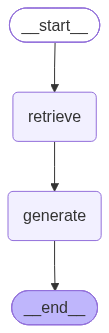

In [34]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
from langchain_core.messages import HumanMessage

query="연봉 4천만원 직장인의 소득세는 얼마인가요?"
initial_state: AgentState = {
      "query": query,
      "context":[],
      "answer":''
  }
graph.invoke(initial_state)

{'query': '연봉 4천만원 직장인의 소득세는 얼마인가요?',
 'context': [Document(id='6ce2a828-dd6b-4b46-8e68-ce76a2e66295', metadata={'source': '../docs/income_tax.txt'}, page_content='5년 이하: 30만원 → 납입연수\n5년 초과 10년 이하: 150만원 + 50만원 × (납입연수 - 5년)\n10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. \n<대통령 2014. 12. 23.>\n<전문개정 2009. 12. 31.>\n제64조(부동산매매업자에 대한 세액 계산의 특례)\n1) 대통령령으로 정하는 부동산매매업(이하 “부동산매매업”이라 한다)을 영위하는 거주자가 이하 “부동산매매업자”라 한다)로서 종합소득세법에 제104조제1항제1호(본항을 포함한다) 및 제103조 또는 같은 조 제7항 각 호의 어느 하나에 해당하는 자산의 매매자익(이하 “주택등매매차익”이라 한다)이 있는 자의 종합소득 산출세액은 다음 각 호의 세액 중 많은 것으로 한다. \n<개정 2014. 12. 23., 2017. 12. 19., 2020. 12. 29.>\n1. 종합소득 산출세액\n\n다음 각 목에 따른 세액의 합계액\n  가. 주택등매매차익에 따른 세율을 적용하여 산출한 세액의 합계액\n  나. 종합소득세법 제55조에 따라 주택등매매차익에 대한 개별세액을 공제한 금액을 과세표준으로 하고 이에 제55조에 따른 세율을 적용하여 산출세액'),
  Document(id='8a5532d7-27ad-4836-a7de-5f82b7c336c2', metadata={'source': '../docs/income_tax.txt'}, page_content='이자소득에 대해서는 다음과 같이

In [ ]:
### 그래프를 시퀀스 형태로 묶어서 쓰기 ,, <retrieve -> generate>

sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])

In [48]:
sequence_graph_builder.add_edge(START,'retrieve')
sequence_graph_builder.add_edge('generate',END)

In [49]:
sequence_graph = sequence_graph_builder.compile()

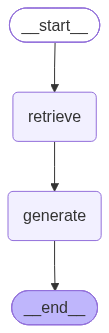

In [50]:
from IPython.display import Image, display

display(Image(sequence_graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state:AgentState = {'query':'연봉 5천만원의 직작인의 소득세는 얼마인가요? 추정치 금액만 알려주세요!'}
graph.invoke(initial_state)

{'query': '연봉 5천만원의 직작인의 소득세는 얼마인가요? 추정치 금액만 알려주세요!',
 'context': [Document(id='6ce2a828-dd6b-4b46-8e68-ce76a2e66295', metadata={'source': '../docs/income_tax.txt'}, page_content='5년 이하: 30만원 → 납입연수\n5년 초과 10년 이하: 150만원 + 50만원 × (납입연수 - 5년)\n10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. \n<대통령 2014. 12. 23.>\n<전문개정 2009. 12. 31.>\n제64조(부동산매매업자에 대한 세액 계산의 특례)\n1) 대통령령으로 정하는 부동산매매업(이하 “부동산매매업”이라 한다)을 영위하는 거주자가 이하 “부동산매매업자”라 한다)로서 종합소득세법에 제104조제1항제1호(본항을 포함한다) 및 제103조 또는 같은 조 제7항 각 호의 어느 하나에 해당하는 자산의 매매자익(이하 “주택등매매차익”이라 한다)이 있는 자의 종합소득 산출세액은 다음 각 호의 세액 중 많은 것으로 한다. \n<개정 2014. 12. 23., 2017. 12. 19., 2020. 12. 29.>\n1. 종합소득 산출세액\n\n다음 각 목에 따른 세액의 합계액\n  가. 주택등매매차익에 따른 세율을 적용하여 산출한 세액의 합계액\n  나. 종합소득세법 제55조에 따라 주택등매매차익에 대한 개별세액을 공제한 금액을 과세표준으로 하고 이에 제55조에 따른 세율을 적용하여 산출세액'),
  Document(id='55ad7361-4830-4a17-adf8-50a76802961c', metadata={'source': '../docs/income_tax.txt'}, page_content='1

In [57]:
initial_state:AgentState = {'query':'연봉 5천만원의 직작인의 소득세는 얼마인가요? 추정치 금액만 알려주세요!'}
ans = sequence_graph.invoke(initial_state)
ans['answer'].content

'연봉 5천만 원의 직장인의 소득세는 약 624만 원입니다.'